In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/retail-sales-forecasting/mock_kaggle.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mpp
import seaborn as sb
%matplotlib inline

In [3]:
data=pd.read_csv("../input/retail-sales-forecasting/mock_kaggle.csv")
data

,data,venda,estoque,preco
0,2014-01-01,0,4972,1.29
1,2014-01-02,70,4902,1.29
2,2014-01-03,59,4843,1.29
3,2014-01-04,93,4750,1.29
4,2014-01-05,96,4654,1.29
...,...,...,...,...
932,2016-07-27,98,3179,2.39
933,2016-07-28,108,3071,2.39
934,2016-07-29,128,4095,2.39
935,2016-07-30,270,3825,2.39


In [4]:
data.head()

,data,venda,estoque,preco
0,2014-01-01,0,4972,1.29
1,2014-01-02,70,4902,1.29
2,2014-01-03,59,4843,1.29
3,2014-01-04,93,4750,1.29
4,2014-01-05,96,4654,1.29


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     937 non-null    object 
 1   venda    937 non-null    int64  
 2   estoque  937 non-null    int64  
 3   preco    937 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 29.4+ KB


In [6]:
data.describe()

,venda,estoque,preco
count,937.000000,937.000000,937.000000
mean,90.533618,1608.258271,1.592572
std,80.682089,1356.691877,0.529502
min,0.000000,0.000000,0.000000
25%,33.000000,794.000000,1.290000
50%,76.000000,1348.000000,1.390000
75%,127.000000,1964.000000,1.890000
max,542.000000,7228.000000,2.980000


In [7]:
data.tail()

,data,venda,estoque,preco
932,2016-07-27,98,3179,2.39
933,2016-07-28,108,3071,2.39
934,2016-07-29,128,4095,2.39
935,2016-07-30,270,3825,2.39
936,2016-07-31,183,3642,2.39


In [8]:
data.isnull()

,data,venda,estoque,preco
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
932,False,False,False,False
933,False,False,False,False
934,False,False,False,False
935,False,False,False,False


In [9]:
data.isnull().sum()

data       0
venda      0
estoque    0
preco      0
dtype: int64

In [10]:
data.shape

(937, 4)

In [11]:
data.columns

Index(['data', 'venda', 'estoque', 'preco'], dtype='object')

In [12]:
data = data.rename(columns = {'data':'Date', 
                              'venda': 'Sales', 
                              'estoque': 'Stock', 
                              'preco': 'Price'})

In [13]:
data.head()

,Date,Sales,Stock,Price
0,2014-01-01,0,4972,1.29
1,2014-01-02,70,4902,1.29
2,2014-01-03,59,4843,1.29
3,2014-01-04,93,4750,1.29
4,2014-01-05,96,4654,1.29


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    937 non-null    object 
 1   Sales   937 non-null    int64  
 2   Stock   937 non-null    int64  
 3   Price   937 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 29.4+ KB


In [15]:
data.tail()

,Date,Sales,Stock,Price
932,2016-07-27,98,3179,2.39
933,2016-07-28,108,3071,2.39
934,2016-07-29,128,4095,2.39
935,2016-07-30,270,3825,2.39
936,2016-07-31,183,3642,2.39


In [16]:
data.describe()

,Sales,Stock,Price
count,937.000000,937.000000,937.000000
mean,90.533618,1608.258271,1.592572
std,80.682089,1356.691877,0.529502
min,0.000000,0.000000,0.000000
25%,33.000000,794.000000,1.290000
50%,76.000000,1348.000000,1.390000
75%,127.000000,1964.000000,1.890000
max,542.000000,7228.000000,2.980000


In [17]:
data.isnull().sum()

Date     0
Sales    0
Stock    0
Price    0
dtype: int64

# Here the data has features Sales, Stock, Price datewise. We added Revenue as new feature in addition to splitting the date column into day, month and year.

In [18]:
data['Date'] = pd.to_datetime(data['Date'])

In [19]:
data['Day'] = data['Date'].dt.day
data['Month'] = data['Date'].dt.month
data['Year'] = data['Date'].dt.year
data['Revenue'] = data['Sales'] * data['Price']

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     937 non-null    datetime64[ns]
 1   Sales    937 non-null    int64         
 2   Stock    937 non-null    int64         
 3   Price    937 non-null    float64       
 4   Day      937 non-null    int32         
 5   Month    937 non-null    int32         
 6   Year     937 non-null    int32         
 7   Revenue  937 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int32(3), int64(2)
memory usage: 47.7 KB


In [21]:
data.describe()

,Date,Sales,Stock,Price,Day,Month,Year,Revenue
count,937,937.000000,937.000000,937.000000,937.000000,937.000000,937.000000,937.000000
mean,2015-04-19 12:23:49.242262528,90.533618,1608.258271,1.592572,15.734258,5.975454,2014.844184,148.226083
min,2014-01-01 00:00:00,0.000000,0.000000,0.000000,1.000000,1.000000,2014.000000,0.000000
25%,2014-08-29 00:00:00,33.000000,794.000000,1.290000,8.000000,3.000000,2014.000000,52.320000
50%,2015-04-20 00:00:00,76.000000,1348.000000,1.390000,16.000000,6.000000,2015.000000,112.230000
75%,2015-12-10 00:00:00,127.000000,1964.000000,1.890000,23.000000,9.000000,2015.000000,207.100000
max,2016-07-31 00:00:00,542.000000,7228.000000,2.980000,31.000000,12.000000,2016.000000,870.240000
std,NaN,80.682089,1356.691877,0.529502,8.811586,3.349390,0.766033,144.298915


In [22]:
data.tail()

,Date,Sales,Stock,Price,Day,Month,Year,Revenue
932,2016-07-27,98,3179,2.39,27,7,2016,234.22
933,2016-07-28,108,3071,2.39,28,7,2016,258.12
934,2016-07-29,128,4095,2.39,29,7,2016,305.92
935,2016-07-30,270,3825,2.39,30,7,2016,645.30
936,2016-07-31,183,3642,2.39,31,7,2016,437.37


In [23]:
data.set_index('Date', inplace=True)

<Axes: xlabel='Date'>

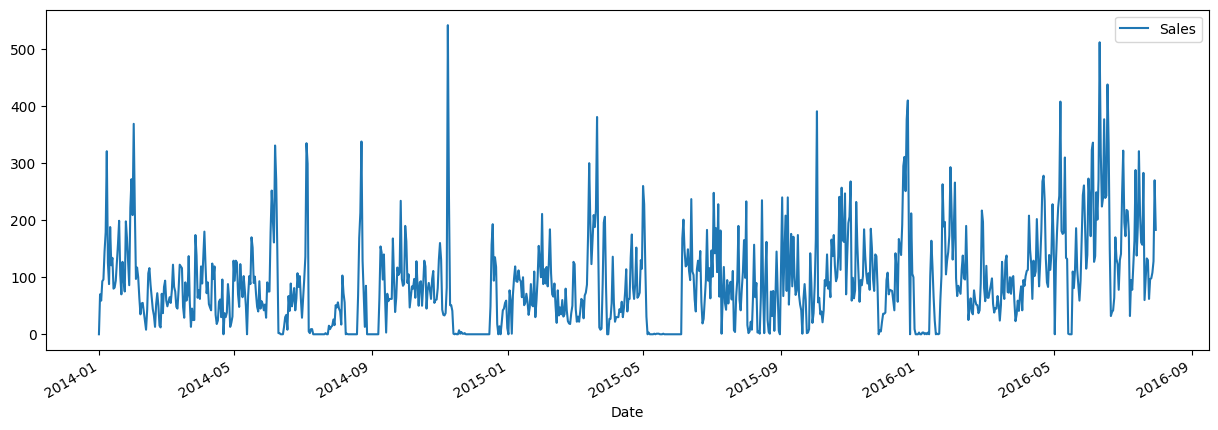

In [24]:
data['Sales'].plot(figsize = (15,5), legend = True)

<Axes: xlabel='Date'>

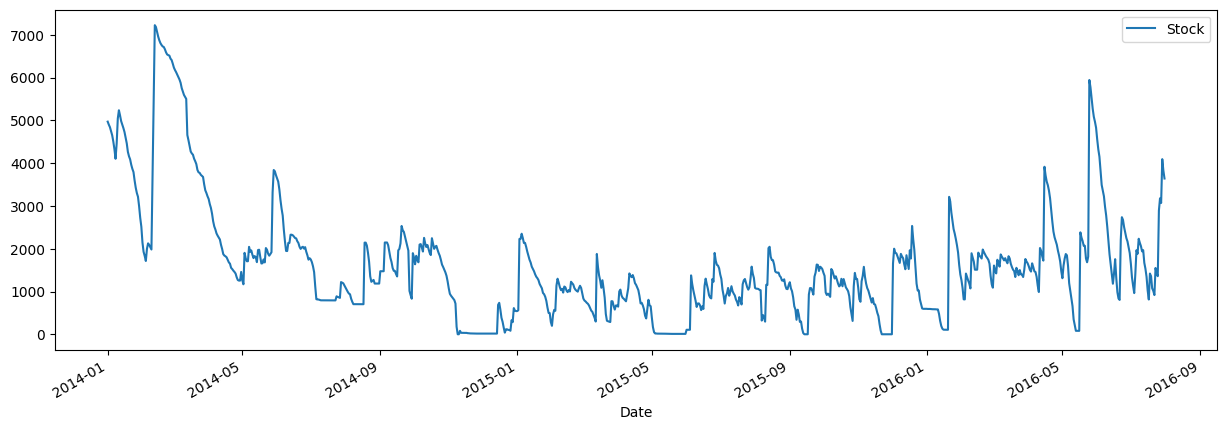

In [25]:
data['Stock'].plot(figsize = (15,5), legend = True)

<Axes: xlabel='Date'>

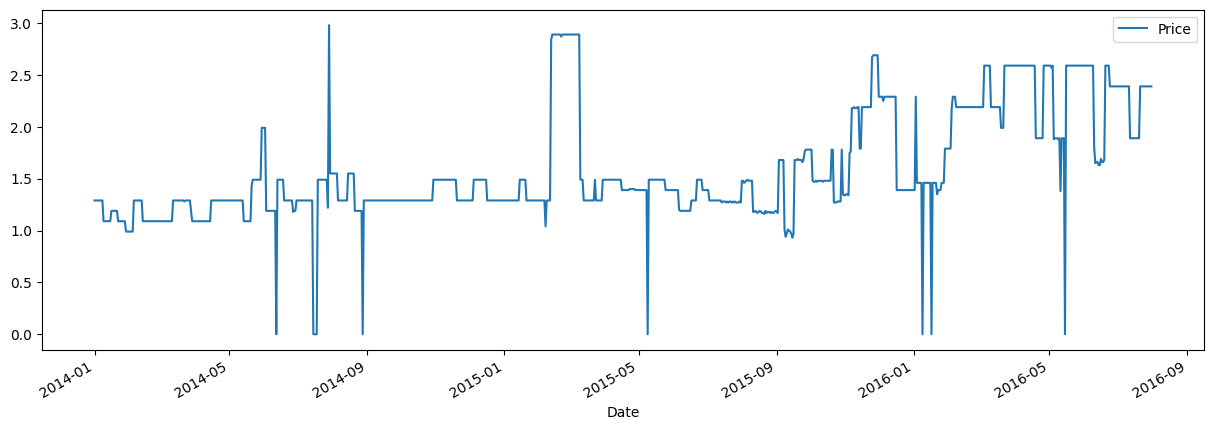

In [26]:
data['Price'].plot(figsize = (15,5), legend = True)

<Axes: xlabel='Date'>

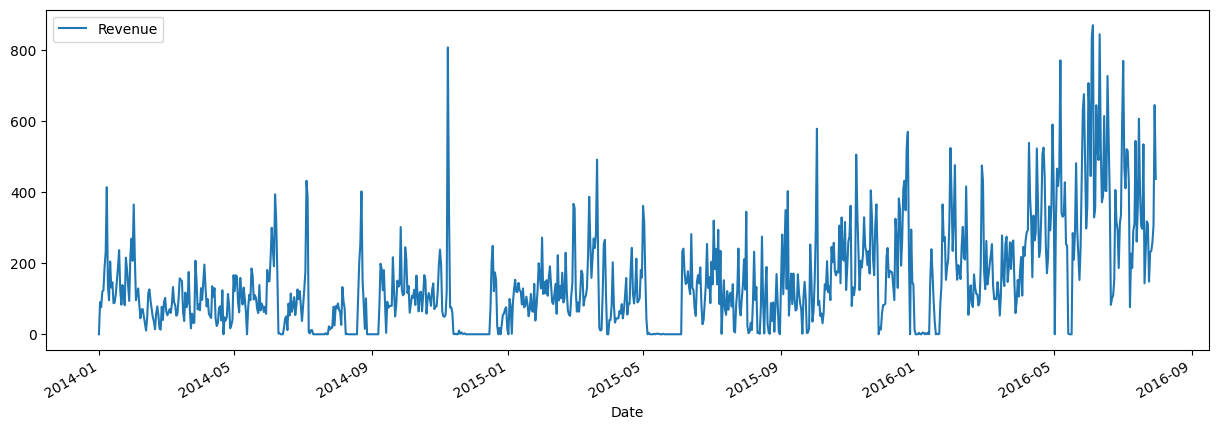

In [27]:
data['Revenue'].plot(figsize = (15,5), legend = True)

# **from the above plots we can say that there is no trend but there is seasonality**

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

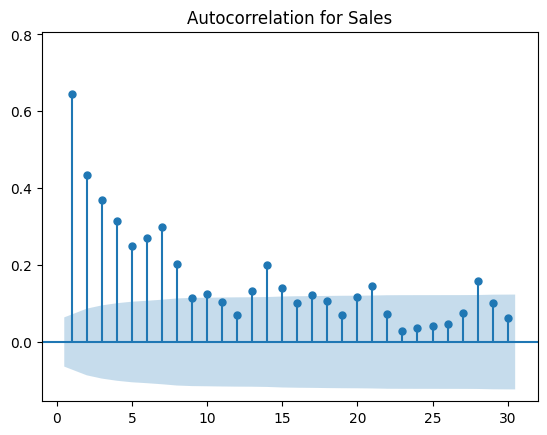

In [29]:
plot_acf(data['Sales'], lags = 30, title='Autocorrelation for Sales', zero=False, auto_ylims=True)
mpp.show()

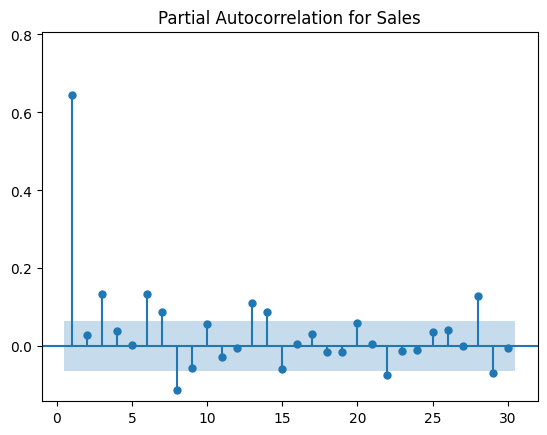

In [30]:
plot_pacf(data['Sales'], lags = 30, title='Partial Autocorrelation for Sales', zero=False, auto_ylims=True)
mpp.show()

# Since the data has no significant trend but there is seasonality we can opt for models like Holt Winters Exponential Smoothing(seasonality).

In [31]:
import statsmodels.tsa.stattools as sts
sts.adfuller(data['Sales'])

(-5.326902281189405,
 4.815089201365774e-06,
 14,
 922,
 {'1%': -3.437462363899248,
  '5%': -2.8646798473884134,
  '10%': -2.568441851017076},
 10080.058794702525)

In [32]:
sts.adfuller(data['Stock'])

(-4.432775258132062,
 0.0002596009817819147,
 1,
 935,
 {'1%': -3.437363201927513,
  '5%': -2.864636122077874,
  '10%': -2.5684185607252137},
 13320.64266001144)

In [33]:
sts.adfuller(data['Price'])

(-4.5854371741841495,
 0.00013739285676424819,
 2,
 934,
 {'1%': -3.4373707314972766,
  '5%': -2.8646394422797337,
  '10%': -2.5684203292233905},
 -90.17618431524147)

In [34]:
sts.adfuller(data['Revenue'])

(-2.9132086543775038,
 0.04383343030916171,
 21,
 915,
 {'1%': -3.437516929214992,
  '5%': -2.86470390726455,
  '10%': -2.5684546666069457},
 10894.08755939725)

# Here our target variable is Sales and we need to forecast sales hence from now we will only focus on Sales column

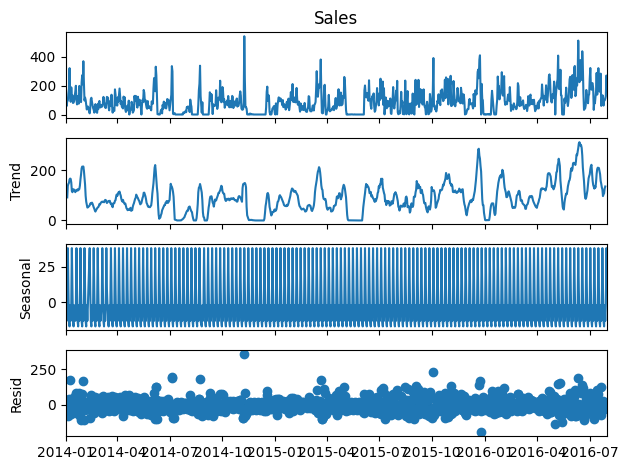

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose
sd_sales = seasonal_decompose(data['Sales'], model='additive', period = 7)
sd_sales.plot()
mpp.show()

<Axes: xlabel='Date'>

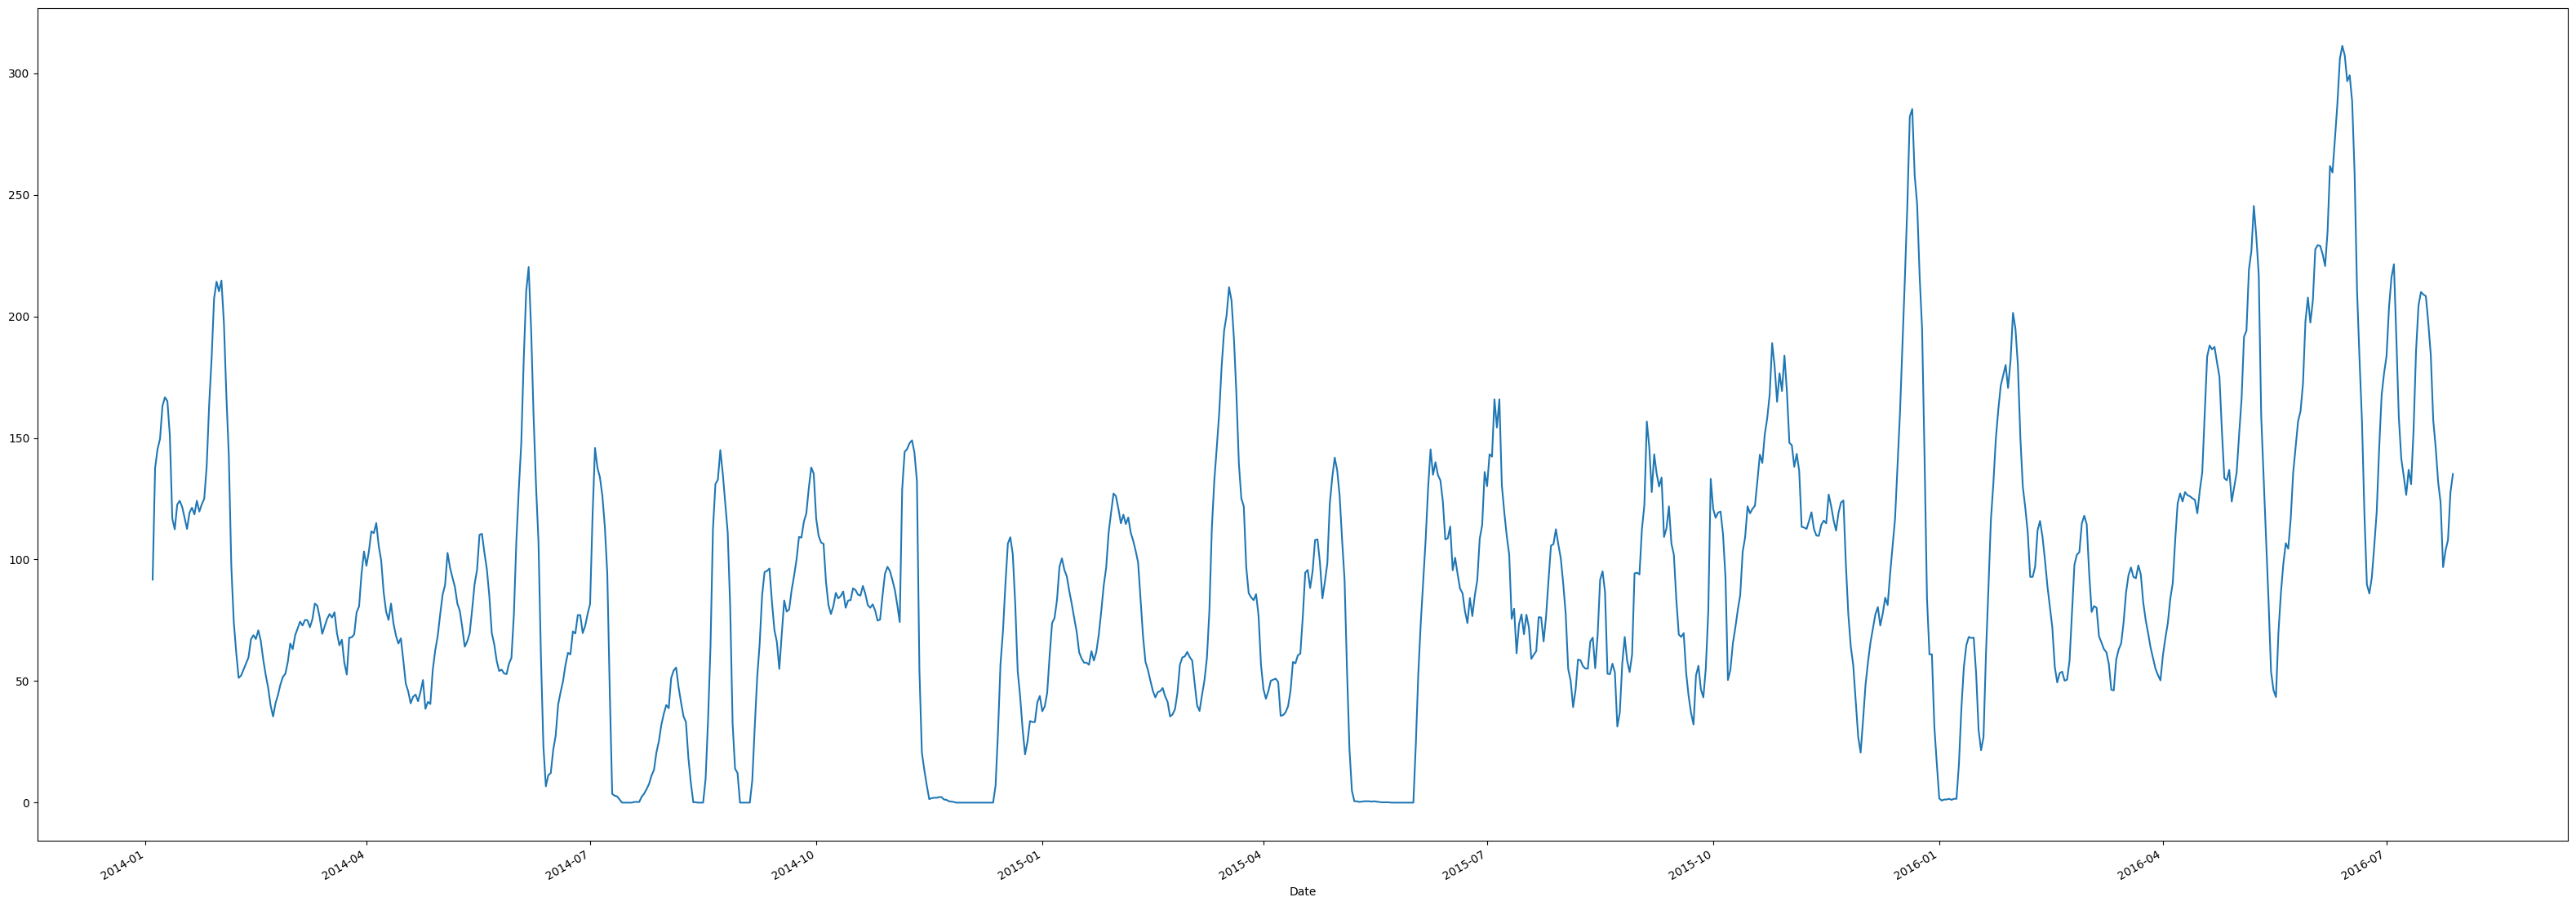

In [36]:
sd_sales.trend.plot(figsize = (40,15))   

In [37]:
data['Sales_Shift'] = data['Sales'].shift(periods = 1)

In [38]:
data.head()

,Sales,Stock,Price,Day,Month,Year,Revenue,Sales_Shift
Date,,,,,,,,
2014-01-01,0,4972,1.29,1,1,2014,0.00,NaN
2014-01-02,70,4902,1.29,2,1,2014,90.30,0.0
2014-01-03,59,4843,1.29,3,1,2014,76.11,70.0
2014-01-04,93,4750,1.29,4,1,2014,119.97,59.0
2014-01-05,96,4654,1.29,5,1,2014,123.84,93.0


In [39]:
data.tail()

,Sales,Stock,Price,Day,Month,Year,Revenue,Sales_Shift
Date,,,,,,,,
2016-07-27,98,3179,2.39,27,7,2016,234.22,97.0
2016-07-28,108,3071,2.39,28,7,2016,258.12,98.0
2016-07-29,128,4095,2.39,29,7,2016,305.92,108.0
2016-07-30,270,3825,2.39,30,7,2016,645.30,128.0
2016-07-31,183,3642,2.39,31,7,2016,437.37,270.0


In [40]:
data.describe()

,Sales,Stock,Price,Day,Month,Year,Revenue,Sales_Shift
count,937.000000,937.000000,937.000000,937.000000,937.000000,937.000000,937.000000,936.000000
mean,90.533618,1608.258271,1.592572,15.734258,5.975454,2014.844184,148.226083,90.434829
std,80.682089,1356.691877,0.529502,8.811586,3.349390,0.766033,144.298915,80.668504
min,0.000000,0.000000,0.000000,1.000000,1.000000,2014.000000,0.000000,0.000000
25%,33.000000,794.000000,1.290000,8.000000,3.000000,2014.000000,52.320000,33.000000
50%,76.000000,1348.000000,1.390000,16.000000,6.000000,2015.000000,112.230000,76.000000
75%,127.000000,1964.000000,1.890000,23.000000,9.000000,2015.000000,207.100000,127.000000
max,542.000000,7228.000000,2.980000,31.000000,12.000000,2016.000000,870.240000,542.000000


In [41]:
data.isnull().sum()

Sales          0
Stock          0
Price          0
Day            0
Month          0
Year           0
Revenue        0
Sales_Shift    1
dtype: int64

<Axes: xlabel='Date'>

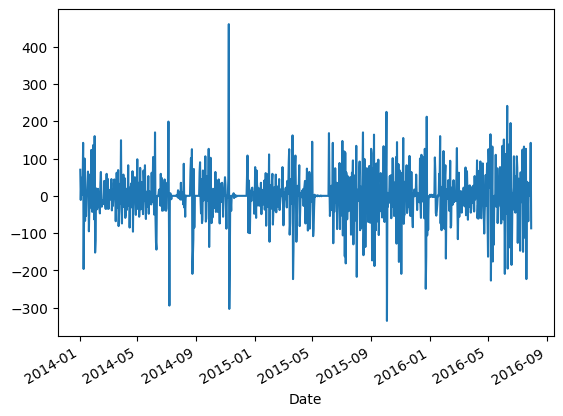

In [42]:
data['diff'] = data['Sales']-data['Sales_Shift']
data['diff'].plot()   